#### Environment Setup & Model Import

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add the parent directory to the system path so we can import model.py
sys.path.append(os.path.abspath('..'))
from model import LivelihoodModel

# Set plotting style for professional look
plt.style.use('seaborn-v0_8-muted')
%matplotlib inline

print("Model logic imported from model.py")

Model logic imported from model.py


#### Population Synthesis

In [2]:
# Initialize a fresh model instance with a fixed seed for reproducibility
model = LivelihoodModel(N=1000, intervention="Control")

# Extract initial state of all 1,000 agents into a DataFrame
agent_data = pd.DataFrame([
    {
        "Agent_ID": a.unique_id, 
        "Farm_Size_Ha": a.farm_size, 
        "Initial_Savings_USD": a.savings, 
        "Initial_Debt_USD": a.debt,
        "Is_Impoverished": a.is_impoverished
    } 
    for a in model.agents
])

print(f"Successfully synthesized {len(agent_data)} unique farmer agents.")
agent_data.head()

Successfully synthesized 1000 unique farmer agents.


,Agent_ID,Farm_Size_Ha,Initial_Savings_USD,Initial_Debt_USD,Is_Impoverished
0,1,0.550521,557.133347,1000,False
1,2,2.338980,717.944422,0,False
2,3,0.151589,472.825387,0,False
3,4,1.649647,227.728223,0,True
4,5,7.516881,515.124791,1000,False


#### Visualizing the Land Tenure Gap

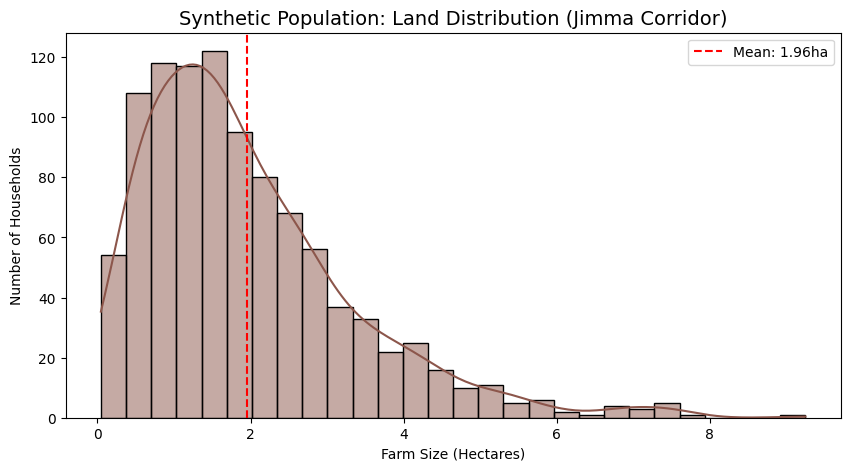

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(agent_data['Farm_Size_Ha'], kde=True, color='#8c564b')

plt.title("Synthetic Population: Land Distribution (Jimma Corridor)", fontsize=14)
plt.xlabel("Farm Size (Hectares)")
plt.ylabel("Number of Households")
plt.axvline(agent_data['Farm_Size_Ha'].mean(), color='red', linestyle='--', label=f"Mean: {agent_data['Farm_Size_Ha'].mean():.2f}ha")

plt.legend()
plt.show()

#### Financial Health Baseline

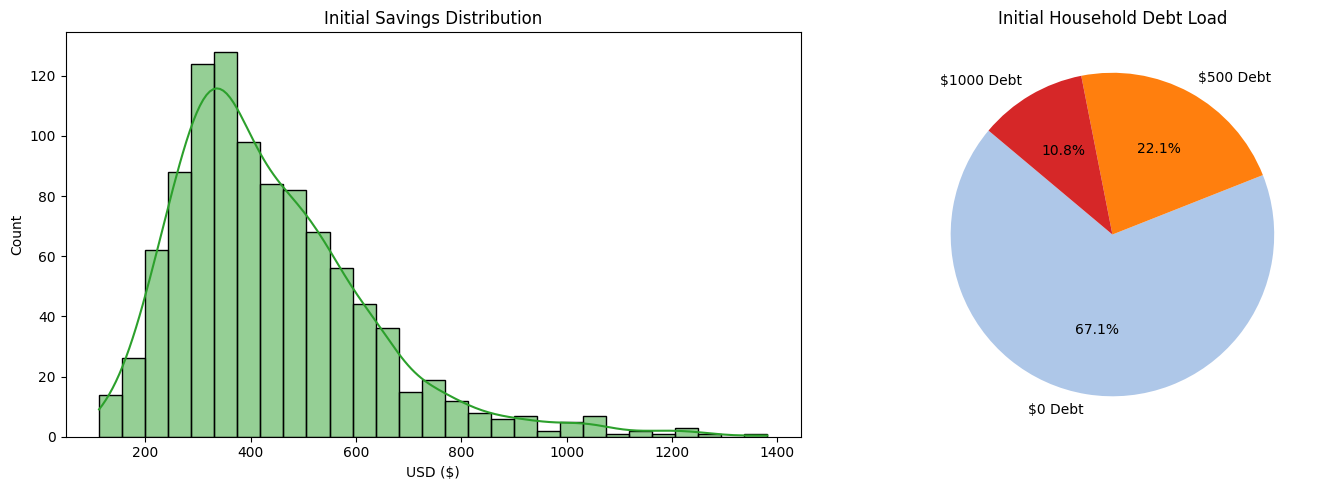

Baseline Poverty Rate at Month 0: 23.10%


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Savings Distribution
sns.histplot(agent_data['Initial_Savings_USD'], kde=True, ax=ax1, color='#2ca02c')
ax1.set_title("Initial Savings Distribution")
ax1.set_xlabel("USD ($)")

# 2. Debt Burden Analysis
debt_counts = agent_data['Initial_Debt_USD'].value_counts()
ax2.pie(debt_counts, labels=[f"${k} Debt" for k in debt_counts.index], 
        autopct='%1.1f%%', colors=['#aec7e8', '#ff7f0e', '#d62728'], startangle=140)
ax2.set_title("Initial Household Debt Load")

plt.tight_layout()
plt.show()

# Print the starting Poverty Rate
initial_poverty = agent_data['Is_Impoverished'].mean() * 100
print(f"Baseline Poverty Rate at Month 0: {initial_poverty:.2f}%")

#### Data Export

In [5]:
# Create the directory if it doesn't exist
os.makedirs('../data/results', exist_ok=True)

# Save the census to CSV
agent_data.to_csv('../data/results/synthetic_population_baseline.csv', index=False)

print("Population census saved to data/results/synthetic_population_baseline.csv")

Population census saved to data/results/synthetic_population_baseline.csv
